# Análisis exploratorio de los viajes de taxi de Nueva York (2024, 2025 y 2026)

Este notebook responde las preguntas del Ejercicio 4. Usa DuckDB para consultar la tabla `trips`, que está en
`data/processed/taxi.duckdb` y que crea `scripts/create_database.py` a partir de los archivos Parquet que publica la
NYC TLC, la oficina que regula los taxis de la ciudad. Las mismas consultas, con su explicación, están en `sql/analysis.sql`.

## Preguntas

1. ¿Cuántos viajes hay cada mes?
2. ¿Cuál es la distancia promedio de un viaje?
3. ¿Cuál es la tarifa promedio?
4. ¿Qué diferencias hay entre los taxis amarillos (yellow) y los verdes (green)?
5. ¿Cómo cambia la cantidad de viajes según la hora y el día de la semana?
6. ¿Qué formas de pago se usan más?
7. ¿Qué valores raros o errores aparecen en los datos?
8. ¿Qué hallazgos importantes se pueden sacar?

## Dos cuidados que se tienen en todo el notebook

El primero es que 2026 solo tiene los meses que la TLC ya publicó. Comparar un año completo contra uno a medias no sería
justo, entonces las comparaciones entre años usan solo los meses comunes, que son los meses que existen en todos los años.
Esos meses se calculan a partir de los datos (ver `MESES_COMUNES` en la primera celda de código). Otras comparaciones usan
porcentajes, que no dependen de cuántos meses haya.

El segundo es que los promedios usan solo viajes válidos, que son los que tienen una distancia entre 0 y 100 millas, una
tarifa entre 0 y 1,000 dólares y una duración entre 0 y 24 horas. Los valores fuera de esos rangos son errores al anotar los
datos y cambiarían mucho los promedios. Esto se explica en `docs/data_quality.md`.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

RUTA_DB = next(p for p in (Path("data/processed/taxi.duckdb"), Path("../data/processed/taxi.duckdb")) if p.exists())
con = duckdb.connect(str(RUTA_DB), read_only=True)

COLOR = {"yellow": "#E0A100", "green": "#2E8B57"}
# Un color por anio (orden fijo); el tipo de taxi se distingue por panel o por su color propio.
COLOR_ANIO = dict(zip(con.execute("SELECT DISTINCT year FROM trips ORDER BY year").fetchnumpy()["year"].tolist(),
                      ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7"]))
# Meses publicados en todos los anios: base de las comparaciones anuales homogeneas.
MESES_COMUNES = "month IN (SELECT month FROM trips GROUP BY month HAVING count(DISTINCT year) = (SELECT count(DISTINCT year) FROM trips))"
VALIDO = "trip_distance > 0 AND trip_distance < 100 AND fare_amount > 0 AND fare_amount < 1000 AND duration_minutes > 0 AND duration_minutes < 1440"
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})

def q(sql):
    return con.execute(sql).fetchdf()

q("SELECT taxi_type, year, count(*) AS viajes, min(month) AS mes_min, max(month) AS mes_max FROM trips GROUP BY ALL ORDER BY ALL")

,taxi_type,year,viajes,mes_min,mes_max
0,green,2024,660218,1,12
1,green,2025,591375,1,12
2,green,2026,337114,1,8
3,yellow,2024,41169720,1,12
4,yellow,2025,48722602,1,12
5,yellow,2026,29703355,1,8


## P1. Viajes por mes

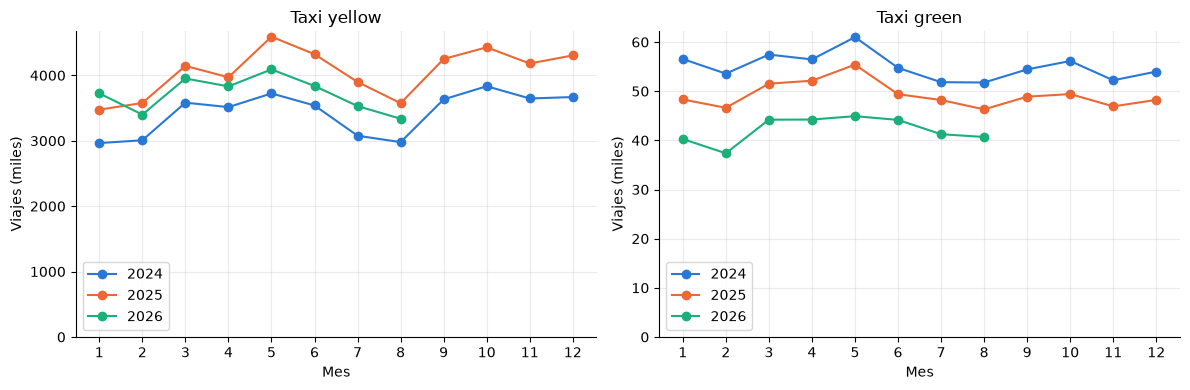

,taxi_type,year,mes_min,mes_max,viajes_meses_comunes,cambio_vs_anio_anterior_pct
0,green,2024,1,8,443415,NaN
1,green,2025,1,8,397918,-10.3
2,green,2026,1,8,337114,-15.3
3,yellow,2024,1,8,26388179,NaN
4,yellow,2025,1,8,31556438,19.6
5,yellow,2026,1,8,29703355,-5.9


In [2]:
mensual = q("SELECT taxi_type, year, month, count(*) AS viajes FROM trips GROUP BY ALL ORDER BY ALL")
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
for eje, tipo in zip(ejes, ("yellow", "green")):
    for anio, color in COLOR_ANIO.items():
        d = mensual[(mensual.taxi_type == tipo) & (mensual.year == anio)]
        eje.plot(d.month, d.viajes / 1000, marker="o", color=color, label=str(anio))
    eje.set_title(f"Taxi {tipo}"); eje.set_xlabel("Mes"); eje.set_ylabel("Viajes (miles)")
    eje.set_xticks(range(1, 13)); eje.set_ylim(bottom=0); eje.legend()
plt.tight_layout(); plt.show()

comparable = q(f"SELECT taxi_type, year, min(month) AS mes_min, max(month) AS mes_max, count(*) AS viajes_meses_comunes FROM trips WHERE {MESES_COMUNES} GROUP BY taxi_type, year ORDER BY ALL")
comparable["cambio_vs_anio_anterior_pct"] = comparable.groupby("taxi_type").viajes_meses_comunes.pct_change().mul(100).round(1)
comparable

### Qué muestra

Yellow tiene entre 3.0 y 4.6 millones de viajes al mes y green entre 37 mil y 61 mil, así que green es apenas el 1.1 % a
1.6 % de todos los viajes. Los tres años siguen la misma temporada. Marzo, mayo y octubre son meses fuertes, y enero,
febrero, julio y agosto son más bajos.

Si se comparan solo los meses comunes (enero a agosto), yellow crece 19.6 % de 2024 a 2025, de 26.4 a 31.6 millones de
viajes, y después baja 5.9 % en 2026, a 29.7 millones. 2025 fue el año con más viajes. Green baja todos los años, 10.3 %
en 2025 y 15.3 % en 2026, y pasa de 443 mil a 398 mil y a 337 mil viajes.

In [3]:
resumen = q(f'''
SELECT taxi_type, year, count(*) AS viajes_validos,
       round(avg(trip_distance), 2) AS dist_prom_millas, round(median(trip_distance), 2) AS dist_mediana,
       round(avg(fare_amount), 2) AS tarifa_prom_usd, round(median(fare_amount), 2) AS tarifa_mediana,
       round(avg(total_amount), 2) AS total_prom_usd, round(avg(duration_minutes), 1) AS duracion_prom_min
FROM trips WHERE {VALIDO} GROUP BY ALL ORDER BY ALL''')
resumen

,taxi_type,year,viajes_validos,dist_prom_millas,dist_mediana,tarifa_prom_usd,tarifa_mediana,total_prom_usd,duracion_prom_min
0,green,2024,623736,2.95,1.97,18.17,13.5,24.22,19.9
1,green,2025,561700,3.19,2.06,18.02,13.5,25.20,21.4
2,green,2026,319447,3.31,2.12,17.16,13.5,25.48,21.1
3,yellow,2024,39702640,3.42,1.80,19.81,14.2,28.64,17.6
4,yellow,2025,44169438,3.49,1.89,20.02,14.2,28.85,17.6
5,yellow,2026,28229185,3.52,1.93,21.30,15.6,30.25,17.9


## P2 y P3. Distancia y tarifa promedio

### Qué muestra

El viaje yellow promedio mide entre 3.4 y 3.5 millas. Su tarifa promedio pasa de 19.8 dólares en 2024 a 20.0 en 2025 y a
21.3 en 2026. La subida de 2026 también se ve en la mediana, que pasa de 14.2 a 15.6 dólares, así que no la causan unos
pocos viajes caros.

La mediana es el valor del medio, o sea, la mitad de los viajes está por debajo y la otra mitad por encima. Aquí la
mediana (de 1.8 a 1.9 millas y de 14.2 a 15.6 dólares) es mucho menor que el promedio. Eso pasa porque hay pocos viajes muy
largos, como los que van a los aeropuertos o fuera de la ciudad, que suben el promedio. Por eso la mediana describe mejor
un viaje normal. En green la distancia sube cada año (2.95, 3.19 y 3.31 millas) mientras la tarifa promedio baja (18.2,
18.0 y 17.2 dólares).

## P4. Diferencias entre yellow y green

In [4]:
comparacion = q(f'''
SELECT taxi_type, count(*) AS viajes_validos,
       round(avg(trip_distance), 2) AS distancia_prom, round(avg(fare_amount), 2) AS tarifa_prom,
       round(avg(tip_amount), 2) AS propina_prom, round(100 * sum(tip_amount) / sum(fare_amount), 1) AS propina_pct_tarifa,
       round(avg(duration_minutes), 1) AS duracion_min, round(avg(passenger_count), 2) AS pasajeros_prom,
       round(avg(trip_distance / (duration_minutes / 60.0)), 1) AS velocidad_mph
FROM trips WHERE {VALIDO} GROUP BY ALL ORDER BY ALL''')
display(comparacion)
zonas = q('''
SELECT taxi_type, pu_location_id AS zona_origen, count(*) AS viajes FROM trips GROUP BY taxi_type, pu_location_id
QUALIFY row_number() OVER (PARTITION BY taxi_type ORDER BY count(*) DESC) <= 5 ORDER BY taxi_type, viajes DESC''')
zonas

,taxi_type,viajes_validos,distancia_prom,tarifa_prom,propina_prom,propina_pct_tarifa,duracion_min,pasajeros_prom,velocidad_mph
0,green,1504883,3.11,17.90,2.68,15.0,20.7,1.31,17.2
1,yellow,112101263,3.47,20.27,3.12,15.4,17.7,1.30,11.3


,taxi_type,zona_origen,viajes
0,green,74,383279
1,green,75,217960
2,green,95,75696
3,green,43,73575
4,green,166,72594
5,yellow,237,5348077
6,yellow,132,5234055
7,yellow,161,5227295
8,yellow,236,4773199
9,yellow,162,3829034


### Qué muestra

Yellow es el servicio grande, con 112 millones de viajes válidos contra 1.5 millones de green, y también el más caro por
viaje (20.3 contra 17.9 dólares). Green hace viajes un poco más cortos en distancia (3.1 contra 3.5 millas) pero más largos
en tiempo (20.7 contra 17.7 minutos), y va más rápido en promedio (17.2 contra 11.3 millas por hora). Tiene sentido,
porque green trabaja sobre todo fuera del centro de Manhattan, donde hay menos tráfico. La propina como porcentaje de la
tarifa es parecida en los dos (15.0 % y 15.4 %).

Los lugares donde suben los pasajeros también son distintos. En green las zonas con más viajes son la 74 y la 75, que
están en East Harlem. En yellow son la 237, la 132 (el aeropuerto JFK), la 161 y la 236, que están en el centro de
Manhattan.

## P5. Viajes por hora y por día de la semana

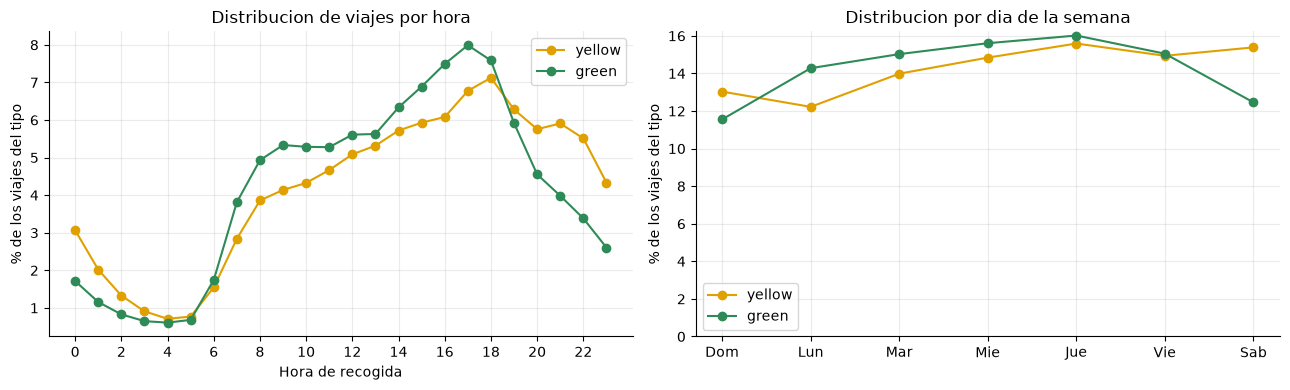

In [5]:
horas = q("SELECT taxi_type, hour(pickup_datetime) AS hora, count(*) AS viajes FROM trips WHERE year(pickup_datetime) = year GROUP BY ALL ORDER BY ALL")
horas["pct"] = horas.viajes / horas.groupby("taxi_type").viajes.transform("sum") * 100
dias = q("SELECT taxi_type, dayofweek(pickup_datetime) AS dia, count(*) AS viajes FROM trips WHERE year(pickup_datetime) = year GROUP BY ALL ORDER BY ALL")
dias["pct"] = dias.viajes / dias.groupby("taxi_type").viajes.transform("sum") * 100
nombres = ["Dom", "Lun", "Mar", "Mie", "Jue", "Vie", "Sab"]

fig, (a, b) = plt.subplots(1, 2, figsize=(13, 4))
for tipo in ("yellow", "green"):
    d = horas[horas.taxi_type == tipo]; a.plot(d.hora, d.pct, marker="o", color=COLOR[tipo], label=tipo)
    d = dias[dias.taxi_type == tipo]; b.plot(d.dia, d.pct, marker="o", color=COLOR[tipo], label=tipo)
a.set_title("Distribucion de viajes por hora"); a.set_xlabel("Hora de recogida"); a.set_ylabel("% de los viajes del tipo"); a.set_xticks(range(0, 24, 2)); a.legend()
b.set_title("Distribucion por dia de la semana"); b.set_xticks(range(7), nombres); b.set_ylabel("% de los viajes del tipo"); b.set_ylim(bottom=0); b.legend()
plt.tight_layout(); plt.show()

### Qué muestra

Los dos servicios tienen pocos viajes entre las 3 y las 5 de la mañana y su punto más alto en la tarde. Yellow llega a su
máximo a las 6 de la tarde (7.1 % de sus viajes) y green a las 5 de la tarde (8.0 %). Green tiene más viajes en horario de
trabajo y menos de madrugada, mientras que yellow mantiene más viajes de noche. A la medianoche todavía tiene el 3.1 % de
sus viajes.

Por día, el jueves es el de más viajes en los dos servicios (15.6 % en yellow y 16.0 % en green), y el domingo y el lunes
son los más bajos en yellow. El sábado es donde más se nota la diferencia. Yellow se mantiene alto (15.4 %) y green baja a
12.5 %.

## P6. Formas de pago

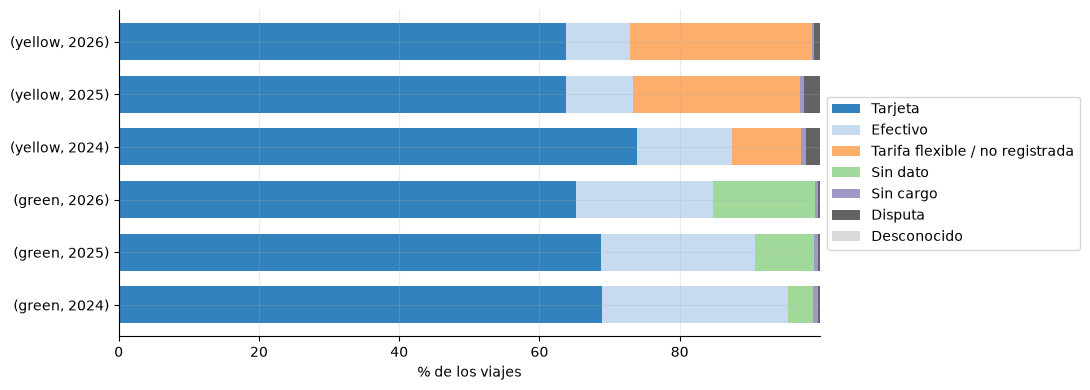

tipo_pago       Tarjeta  Efectivo  Tarifa flexible / no registrada  Sin dato  \
taxi_type year                                                                 
green     2024    68.87     26.51                             0.00      3.68   
          2025    68.76     21.95                             0.00      8.43   
          2026    65.25     19.55                             0.00     14.47   
yellow    2024    73.97     13.46                             9.94      0.00   
          2025    63.74      9.55                            23.83      0.00   
          2026    63.77      9.12                            25.98      0.00   

tipo_pago       Sin cargo  Disputa  Desconocido  
taxi_type year                                   
green     2024       0.70     0.24          0.0  
          2025       0.64     0.21          0.0  
          2026       0.50     0.22          0.0  
yellow    2024       0.71     1.93          0.0  
          2025       0.63     2.25          0.0  
          2026       0.33     0.81          0.0

In [6]:
pagos = q("SELECT taxi_type, year, coalesce(payment_type::VARCHAR, 'sin dato') AS tipo_pago, count(*) AS viajes FROM trips GROUP BY ALL")
pagos["pct"] = pagos.viajes / pagos.groupby(["taxi_type", "year"]).viajes.transform("sum") * 100
etiquetas = {"1": "Tarjeta", "2": "Efectivo", "0": "Tarifa flexible / no registrada", "sin dato": "Sin dato", "3": "Sin cargo", "4": "Disputa", "5": "Desconocido"}
tabla = pagos.pivot_table(index=["taxi_type", "year"], columns="tipo_pago", values="pct", fill_value=0).rename(columns=etiquetas)
orden = [c for c in ["Tarjeta", "Efectivo", "Tarifa flexible / no registrada", "Sin dato", "Sin cargo", "Disputa", "Desconocido"] if c in tabla.columns]
tabla = tabla[orden]
tabla.plot(kind="barh", stacked=True, figsize=(11, 4), colormap="tab20c", width=0.7)
plt.xlabel("% de los viajes"); plt.ylabel(""); plt.legend(loc="center left", bbox_to_anchor=(1, 0.5)); plt.tight_layout(); plt.show()
tabla.round(2)

In [7]:
q(f'''
SELECT taxi_type, year,
       round(avg(fare_amount), 2) AS tarifa_prom,
       round(avg(tip_amount) FILTER (WHERE payment_type = 1), 2) AS propina_prom_tarjeta,
       round(avg(tip_amount), 2) AS propina_prom_todos
FROM trips WHERE {MESES_COMUNES} AND trip_distance > 0 AND trip_distance < 100 AND fare_amount > 0 AND fare_amount < 1000
  AND duration_minutes > 0 AND duration_minutes < 1440
GROUP BY ALL ORDER BY ALL''')

,taxi_type,year,tarifa_prom,propina_prom_tarjeta,propina_prom_todos
0,green,2024,17.88,3.61,2.59
1,green,2025,18.02,3.70,2.71
2,green,2026,17.16,3.81,2.65
3,yellow,2024,19.54,4.30,3.34
4,yellow,2025,19.58,4.28,3.02
5,yellow,2026,21.30,4.26,2.88


### Qué muestra

La tarjeta es la forma de pago principal. En 2024 la usaron el 74 % de los viajes yellow. El gran cambio ocurre en 2025.
En yellow, la categoría `0`, que es tarifa flexible o pago no anotado, pasa de 9.9 % en 2024 a 23.8 % en 2025 y a 26.0 %
en 2026. La tarjeta baja a 63.7 % y el efectivo baja de 13.5 % a 9.1 %. En green, los viajes sin forma de pago anotada
suben de 3.7 % a 8.4 % y a 14.5 %.

En los pagos en efectivo y en la categoría 0 casi nunca queda anotada una propina. Por eso la propina promedio de yellow
baja de 3.34 a 3.02 y a 2.88 dólares. Pero si se miran solo los pagos con tarjeta, la propina promedio casi no cambia (4.30,
4.28 y 4.26 dólares). Lo que cambió fue la forma de pagar, y los pasajeros siguen dejando la misma propina.

## P7. Valores raros y errores en los datos

,taxi_type,year,viajes,distancia_cero,distancia_mayor_100,monto_negativo,monto_mayor_1000,duracion_no_positiva,duracion_mayor_24h,fecha_fuera_del_anio
0,green,2024,660218,34574.0,235.0,2174.0,1.0,662.0,0.0,20.0
1,green,2025,591375,24438.0,209.0,1774.0,1.0,1910.0,2.0,21.0
2,green,2026,337114,12212.0,72.0,1023.0,1.0,234.0,4.0,14.0
3,yellow,2024,41169720,776305.0,1613.0,609344.0,43.0,13510.0,230.0,56.0
4,yellow,2025,48722602,1402958.0,2870.0,973721.0,85.0,546304.0,352.0,29.0
5,yellow,2026,29703355,952231.0,1223.0,161835.0,49.0,371683.0,263.0,17.0


,taxi_type,max_distancia,min_total,max_total,recogida_mas_antigua
0,green,262315.94,-501.5,1678.20,2008-12-31 00:00:00
1,yellow,398608.62,-2560.2,863380.37,2001-01-01 09:23:58


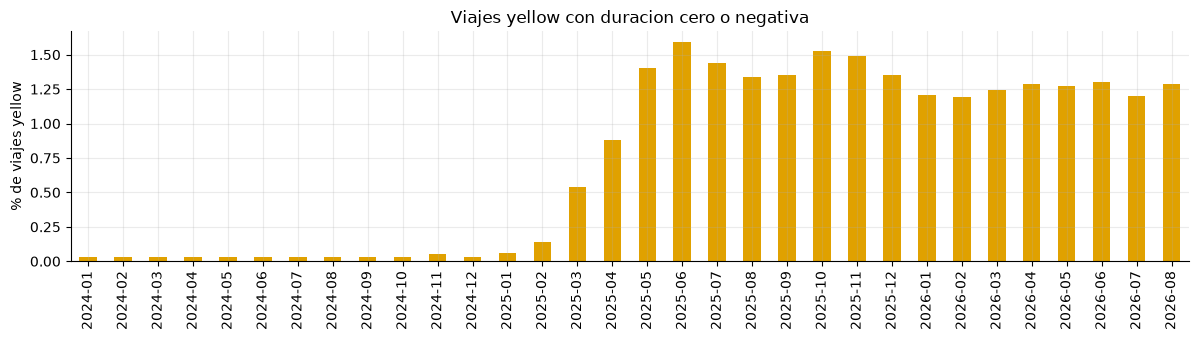

,year,vendor_id,viajes,duracion_no_positiva
0,2024,1,9715918,10999.0
1,2024,2,31451503,1835.0
2,2024,6,2069,446.0
3,2024,7,230,230.0
4,2025,1,9586873,7561.0
5,2025,2,38575846,2059.0
6,2025,6,23982,783.0
7,2025,7,535901,535901.0
8,2026,1,5467071,4301.0
9,2026,2,23809774,258.0


In [8]:
atipicos = q('''
SELECT taxi_type, year, count(*) AS viajes,
       count_if(trip_distance = 0) AS distancia_cero, count_if(trip_distance > 100) AS distancia_mayor_100,
       count_if(total_amount < 0) AS monto_negativo, count_if(total_amount > 1000) AS monto_mayor_1000,
       count_if(duration_minutes <= 0) AS duracion_no_positiva, count_if(duration_minutes > 1440) AS duracion_mayor_24h,
       count_if(year(pickup_datetime) <> year) AS fecha_fuera_del_anio
FROM trips GROUP BY ALL ORDER BY ALL''')
display(atipicos)
extremos = q("SELECT taxi_type, max(trip_distance) AS max_distancia, min(total_amount) AS min_total, max(total_amount) AS max_total, min(pickup_datetime) AS recogida_mas_antigua FROM trips GROUP BY ALL")
display(extremos)

duracion = q("SELECT year, month, round(100.0 * count_if(duration_minutes <= 0) / count(*), 2) AS pct FROM trips WHERE taxi_type = 'yellow' GROUP BY ALL ORDER BY ALL")
duracion["periodo"] = duracion.year.astype(str) + "-" + duracion.month.astype(str).str.zfill(2)
duracion.plot(x="periodo", y="pct", kind="bar", legend=False, color=COLOR["yellow"], figsize=(12, 3.5))
plt.ylabel("% de viajes yellow"); plt.title("Viajes yellow con duracion cero o negativa"); plt.xlabel(""); plt.tight_layout(); plt.show()

q("SELECT year, vendor_id, count(*) AS viajes, count_if(duration_minutes <= 0) AS duracion_no_positiva FROM trips WHERE taxi_type = 'yellow' GROUP BY ALL ORDER BY ALL")

### Qué muestra

Los datos traen muchos errores. Hay distancias de cientos de miles de millas, montos que van desde -2,560 hasta 863,380
dólares y viajes con fechas de 2001 a 2008, que en realidad son errores del reloj del taxi. También son comunes los viajes
con distancia cero (776 mil, 1.40 millones y 952 mil viajes yellow en 2024, 2025 y 2026) y los montos negativos, que son
reembolsos o cancelaciones (609 mil, 974 mil y 162 mil).

Lo que más llama la atención son los viajes con duración cero o negativa. En yellow pasan de 13.5 mil en 2024 a 546 mil en
2025 y 372 mil en 2026. La gráfica por mes muestra que el problema empieza entre febrero y marzo de 2025 y después se queda
en cerca de 1.2 % a 1.6 % de los viajes. Lo causa la empresa con `vendor_id` 7, que aparece en diciembre de 2024 con 230
viajes y crece durante 2025. Todos sus viajes tienen duración cero, y explican el 98.1 % de estos casos en 2025 y el 98.8 %
en 2026. Es un error de cómo esa empresa anota los viajes, porque los viajes reales sí duran algo. Por eso hay que filtrar
por duración antes de calcular promedios.

## P8. Hallazgos

1. Yellow tuvo su año más alto en 2025 y green baja cada año. En los meses comunes (enero a agosto), yellow crece 19.6 % de
   2024 a 2025 y baja 5.9 % en 2026, y green baja 10.3 % y 15.3 %. Con solo 2024 y 2026 se habría pensado que yellow crecía
   sin parar (12.6 %). El año del medio muestra que la tendencia cambió de dirección.
2. El cambio en la forma de pagar en 2025 confunde las propinas. La categoría de pago 0 pasa de 9.9 % a 23.8 % y a 26.0 % de
   los viajes yellow. La propina promedio de todos los viajes baja 14 % (de 3.34 a 2.88 dólares), pero con tarjeta se
   mantiene (4.30, 4.28 y 4.26). Comparar propinas sin separar la forma de pago llevaría a una conclusión equivocada.
3. Yellow y green se usan de forma muy distinta. Green tiene apenas el 1.1 % a 1.6 % de los viajes, va más rápido (17.2
   contra 11.3 millas por hora), tiene la mayoría de sus viajes en East Harlem, su hora pico es a las 5 de la tarde y baja
   el fin de semana. Yellow se mueve más por el aeropuerto y el centro de Manhattan, tiene un sábado fuerte y más viajes de
   madrugada.
4. Una empresa que entra a finales de 2024 trae viajes con duración cero. El `vendor_id` 7 explica el 98 % de esos casos en
   yellow en 2025 y 2026 (536 mil y 367 mil viajes), 40 veces más que todos los de 2024.
5. Los promedios pueden engañar. La mediana de la tarifa yellow (de 14.2 a 15.6 dólares) es entre 25 % y 30 % más baja que
   el promedio, por los pocos viajes largos que suben el promedio.

La evolución de los tres años juntos se analiza en `notebooks/evolucion_2024_2026.ipynb` y en `docs/analisis_tres_anios.md`.